# Code Metrics — Style Transfer Project

Counts **files**, **classes**, **methods**, and **lines of code** for every Python file in the project,
then aggregates them into five categories: `core`, `ml`, `ui`, `tests`, and `ETC`.

## 1 — Import Required Libraries

In [1]:
%matplotlib inline

import ast
import json
import os
from pathlib import Path
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("Libraries loaded.")


Libraries loaded.


## 2 — Define Category Mappings

Files are assigned to a category by matching their path against the patterns below (first match wins).
Anything that doesn't match a known category lands in **ETC**.

In [2]:
# Root of the project (one level up from docs/)
PROJECT_ROOT: Path = Path("..").resolve()

# Ordered list of (path-fragment, category-label).
# First matching rule wins; unmatched files → "ETC".
CATEGORY_RULES: list[tuple[str, str]] = [
    ("src/core",      "core"),
    ("src/trainer",   "trainer"),
    ("src/stylist",   "stylist"),
    ("tests",         "tests"),
    ("docs",          "notebooks"),
]
CATEGORY_ORDER: list[str] = ["core", "trainer", "stylist", "tests", "notebooks", "ETC"]

# Directories to skip entirely
SKIP_DIRS: frozenset[str] = frozenset({".venv", "__pycache__", ".git", ".pytest_cache", ".mypy_cache"})

def assign_category(rel_path: Path) -> str:
    """Return the category label for a file given its path relative to PROJECT_ROOT."""
    parts = rel_path.as_posix()
    for fragment, label in CATEGORY_RULES:
        if parts.startswith(fragment):
            return label
    return "ETC"

print(f"Project root : {PROJECT_ROOT}")
print(f"Category rules: {[r[1] for r in CATEGORY_RULES]} + ETC")


Project root : C:\Users\i09300076\OneDrive - Endress+Hauser\DEV\Python3\style_transfer
Category rules: ['core', 'trainer', 'stylist', 'tests', 'notebooks'] + ETC


## 3 — Scan Project Files and Collect Metrics

Walk the tree, parse every `.py` file with `ast`, and record per-file metrics.

In [3]:
from dataclasses import dataclass, field


@dataclass
class FileMetrics:
    rel_path: str
    category: str
    lines: int
    classes: int
    methods: int


def _count_metrics(py_file: Path) -> tuple[int, int, int]:
    """Return (lines, classes, methods) for a single Python file.

    Falls back to (line_count, 0, 0) if the file cannot be parsed.
    """
    source = py_file.read_text(encoding="utf-8", errors="replace")
    lines = len(source.splitlines())
    try:
        tree = ast.parse(source, filename=str(py_file))
    except SyntaxError:
        return lines, 0, 0

    classes = sum(1 for node in ast.walk(tree) if isinstance(node, ast.ClassDef))
    methods = sum(
        1
        for node in ast.walk(tree)
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef))
    )
    return lines, classes, methods


def _count_ipynb_metrics(nb_file: Path) -> tuple[int, int, int]:
    """Return (code_lines, classes, methods) summed across all code cells."""
    try:
        nb = json.loads(nb_file.read_text(encoding="utf-8", errors="replace"))
    except Exception:
        return 0, 0, 0

    total_lines = 0
    total_classes = 0
    total_methods = 0
    for cell in nb.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        total_lines += len(source.splitlines())
        try:
            tree = ast.parse(source)
            total_classes += sum(1 for node in ast.walk(tree) if isinstance(node, ast.ClassDef))
            total_methods += sum(
                1 for node in ast.walk(tree)
                if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef))
            )
        except SyntaxError:
            pass
    return total_lines, total_classes, total_methods


def scan_project(root: Path) -> list[FileMetrics]:
    """Walk *root* and return one FileMetrics per .py or .ipynb file found."""
    records: list[FileMetrics] = []
    for dirpath, dirnames, filenames in os.walk(root):
        # Prune skip dirs in-place so os.walk won't descend into them
        dirnames[:] = [d for d in dirnames if d not in SKIP_DIRS]
        for fname in sorted(filenames):
            abs_path = Path(dirpath) / fname
            rel_path = abs_path.relative_to(root)
            if fname.endswith(".py"):
                category = assign_category(rel_path)
                lines, classes, methods = _count_metrics(abs_path)
            elif fname.endswith(".ipynb"):
                category = assign_category(rel_path)
                if category != "notebooks":
                    continue
                lines, classes, methods = _count_ipynb_metrics(abs_path)
            else:
                continue
            records.append(FileMetrics(
                rel_path=rel_path.as_posix(),
                category=category,
                lines=lines,
                classes=classes,
                methods=methods,
            ))
    return records


file_metrics: list[FileMetrics] = scan_project(PROJECT_ROOT)
py_count  = sum(1 for fm in file_metrics if fm.rel_path.endswith(".py"))
nb_count  = sum(1 for fm in file_metrics if fm.rel_path.endswith(".ipynb"))
print(f"Scanned {py_count} Python files and {nb_count} notebooks.")
for fm in file_metrics:
    print(f"  {fm.category:<10}  {fm.lines:>4} lines  {fm.classes:>2} cls  {fm.methods:>3} fn  {fm.rel_path}")


Scanned 48 Python files and 4 notebooks.
  ETC           17 lines   0 cls    0 fn  main_image_styler.py
  ETC          170 lines   0 cls    5 fn  main_style_trainer.py
  notebooks    139 lines   0 cls    1 fn  docs/add_style.ipynb
  notebooks    238 lines   1 cls    3 fn  docs/code_metrics.ipynb
  notebooks    290 lines   0 cls    4 fn  docs/kaggle_style_training.ipynb
  notebooks    173 lines   0 cls    4 fn  docs/style_analysis.ipynb
  ETC          181 lines   0 cls    4 fn  scripts/benchmark.py
  ETC          129 lines   0 cls    4 fn  scripts/download_pretrained.py
  ETC          324 lines   8 cls   20 fn  scripts/setup_models.py
  ETC            1 lines   0 cls    0 fn  src/__init__.py
  core           1 lines   0 cls    0 fn  src/core/__init__.py
  core         255 lines   4 cls    6 fn  src/core/engine.py
  core         103 lines   2 cls    7 fn  src/core/models.py
  core         260 lines   2 cls    8 fn  src/core/photo_manager.py
  core         164 lines   3 cls   12 fn  src/c

## 4 — Aggregate Metrics by Category

In [4]:
df_files = pd.DataFrame(
    {
        "category": fm.category,
        "file":     fm.rel_path,
        "lines":    fm.lines,
        "classes":  fm.classes,
        "methods":  fm.methods,
    }
    for fm in file_metrics
)

# Aggregate: files = row count, others = sum
agg = (
    df_files
    .groupby("category", as_index=False)
    .agg(
        files=("file",    "count"),
        lines=("lines",   "sum"),
        classes=("classes", "sum"),
        methods=("methods", "sum"),
    )
)

# Ensure all categories appear even if empty, then sort by canonical order
agg = agg.set_index("category").reindex(CATEGORY_ORDER, fill_value=0).reset_index()
agg.rename(columns={"category": "Category", "files": "Files",
                     "lines": "Lines", "classes": "Classes",
                     "methods": "Methods"}, inplace=True)

# Add percentage columns (% of column total)
for col in ["Files", "Lines", "Classes", "Methods"]:
    col_total = agg[col].sum()
    agg[f"{col}_%"] = ((agg[col] / col_total) * 100).round(1) if col_total > 0 else 0.0

print(agg[["Category", "Files", "Files_%", "Lines", "Lines_%",
           "Classes", "Classes_%", "Methods", "Methods_%"]])


    Category  Files  Files_%  Lines  Lines_%  Classes  Classes_%  Methods  Methods_%
0       core      7     13.5   1058     15.0       13       23.2       42       11.4
1    trainer      6     11.5    659      9.4        9       16.1       24        6.5
2    stylist      9     17.3   1469     20.8        7       12.5       69       18.8
3      tests     20     38.5   2198     31.2       18       32.1      187       51.0
4  notebooks      4      7.7    840     11.9        1        1.8       12        3.3
5        ETC      6     11.5    822     11.7        8       14.3       33        9.0


## 5 — Metrics Table

In [5]:
totals = pd.DataFrame([{
    "Category": "TOTAL",
    "Files":    agg["Files"].sum(),   "Files_%":   100.0,
    "Lines":    agg["Lines"].sum(),   "Lines_%":   100.0,
    "Classes":  agg["Classes"].sum(), "Classes_%": 100.0,
    "Methods":  agg["Methods"].sum(), "Methods_%": 100.0,
}])

display_df = pd.concat([agg, totals], ignore_index=True)

# Build combined "value (pct%)" columns for display
METRIC_COLS = ["Files", "Lines", "Classes", "Methods"]
for col in METRIC_COLS:
    display_df[col] = display_df.apply(
        lambda r, c=col: f"{int(r[c]):,} (100%)"
        if r["Category"] == "TOTAL"
        else f"{int(r[c]):,} ({r[f'{c}_%']:.1f}%)",
        axis=1,
    )

display_df = display_df[["Category"] + METRIC_COLS]

# Style: right-align numeric cols, bold the TOTAL row
styled = (
    display_df.style
    .set_caption("Code Metrics by Category (value / % of total)")
    .set_properties(**{"text-align": "right"}, subset=METRIC_COLS)
    .set_properties(**{"text-align": "left"},  subset=["Category"])
    .apply(
        lambda row: ["font-weight: bold; background-color: #f0f0f0"] * len(row)
                    if row["Category"] == "TOTAL" else [""] * len(row),
        axis=1,
    )
    .hide(axis="index")
)

display(styled)


Category,Files,Lines,Classes,Methods
core,7 (13.5%),"1,058 (15.0%)",13 (23.2%),42 (11.4%)
trainer,6 (11.5%),659 (9.4%),9 (16.1%),24 (6.5%)
stylist,9 (17.3%),"1,469 (20.8%)",7 (12.5%),69 (18.8%)
tests,20 (38.5%),"2,198 (31.2%)",18 (32.1%),187 (51.0%)
notebooks,4 (7.7%),840 (11.9%),1 (1.8%),12 (3.3%)
ETC,6 (11.5%),822 (11.7%),8 (14.3%),33 (9.0%)
TOTAL,52 (100%),"7,046 (100%)",56 (100%),367 (100%)


## 6 — Stacked Bar Chart

Four sub-charts — one per metric — each showing the per-category breakdown as a stacked bar.

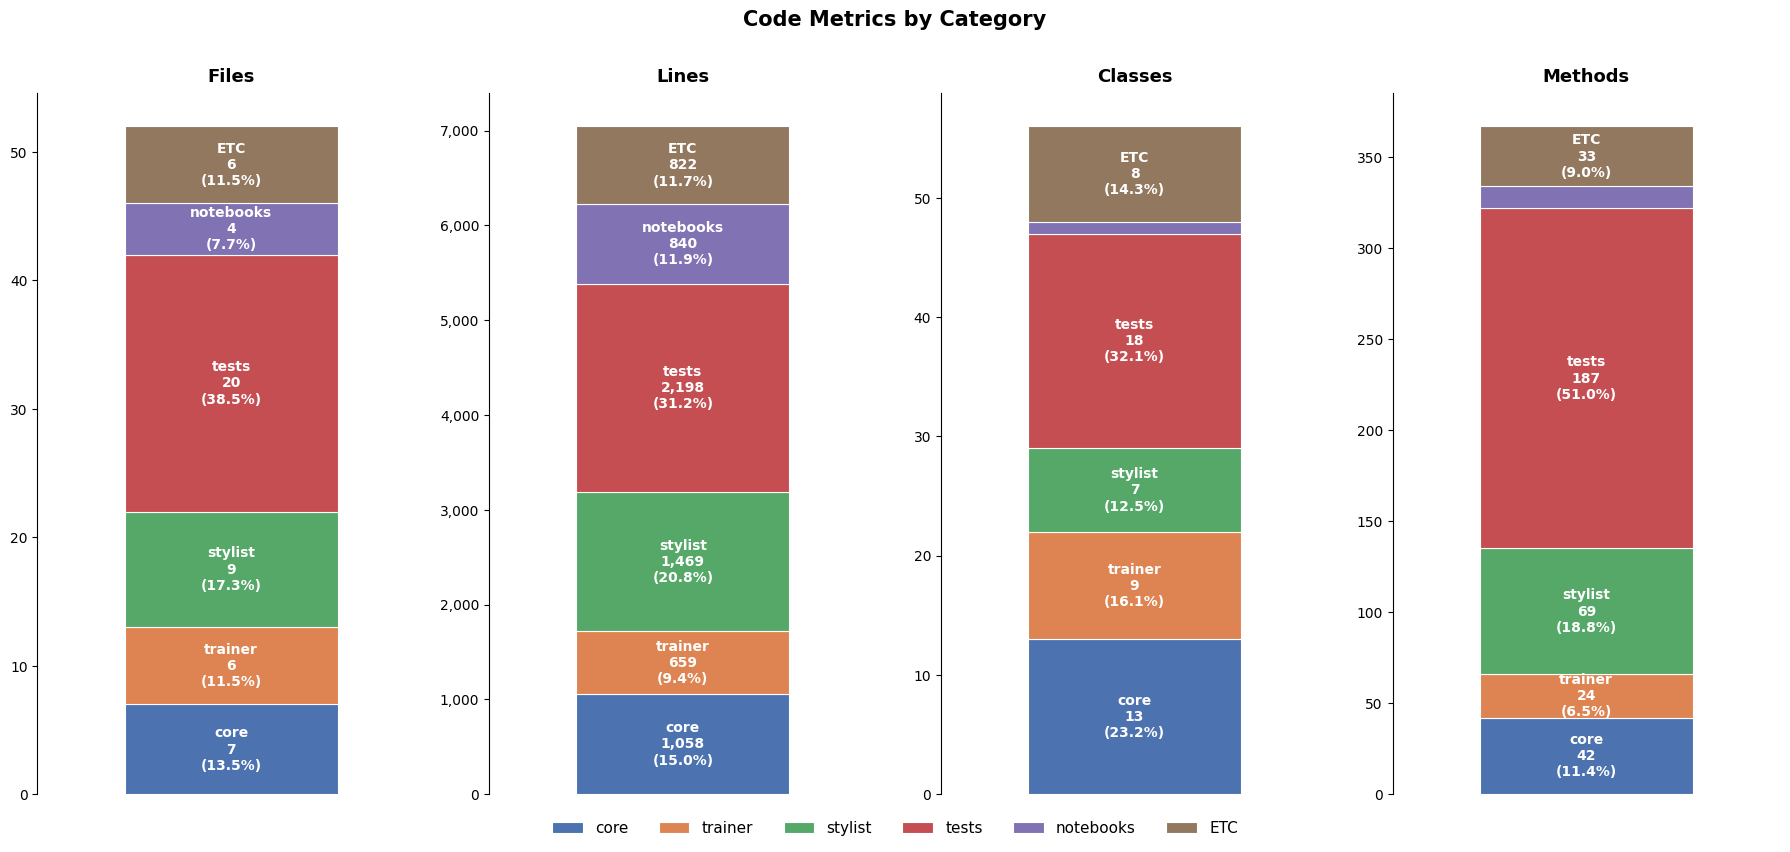

Chart saved to docs/code_metrics_chart.png


In [6]:
METRICS: list[str] = ["Files", "Lines", "Classes", "Methods"]
PALETTE: list[str] = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

# Use only the category rows (drop TOTAL); use raw numeric agg
plot_df = agg.set_index("Category")

fig, axes = plt.subplots(1, 4, figsize=(18, 8))
fig.suptitle("Code Metrics by Category", fontsize=15, fontweight="bold", y=1.01)

BAR_WIDTH = 0.55
LABEL_FONTSIZE = 10

for ax, metric in zip(axes, METRICS):
    values = plot_df[metric].values
    categories = plot_df.index.tolist()
    total = float(sum(values))
    bottom = 0.0
    for i, (cat, val) in enumerate(zip(categories, values)):
        ax.bar(
            0, val,
            bottom=bottom,
            color=PALETTE[i % len(PALETTE)],
            label=cat,
            edgecolor="white",
            linewidth=0.8,
            width=BAR_WIDTH,
        )
        # Only label segments that are large enough to fit text (>= 4 % of total)
        pct = val / total * 100 if total > 0 else 0.0
        if total > 0 and pct >= 4.0:
            ax.text(
                0, bottom + val / 2,
                f"{cat}\n{val:,}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=LABEL_FONTSIZE, color="white", fontweight="bold",
            )
        bottom += val

    ax.set_title(metric, fontsize=13, fontweight="bold", pad=8)
    ax.set_xticks([])
    ax.set_xlim(-0.5, 0.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.tick_params(axis="y", labelsize=10)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

# Single shared legend
handles, labels = axes[-1].get_legend_handles_labels()
seen: dict[str, Any] = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(
    seen.values(), seen.keys(),
    loc="lower center", ncol=len(CATEGORY_ORDER),
    frameon=False, fontsize=11,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.savefig("code_metrics_chart.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print("Chart saved to docs/code_metrics_chart.png")
